# Supervised Learning Algorithms




In [4]:
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
cancer = load_breast_cancer()
iris = load_iris()
diabetes = load_diabetes()
from sklearn.preprocessing import StandardScaler


In [5]:
# load housing dataset (saved on your gdrive - check the Dataset folder on Onedrive)

# First mount google drive to be usable and reachable as data storage in colab
from google.colab import drive
drive.mount('/content/drive')

# define path to file
filename = '/content/drive/MyDrive/Teaching/MLP/2024_spring/Datasets/housing.pkl'

# import pickle package to deal with pkl data
import pickle
with open(filename, 'rb') as bunch:
    housing = pickle.load(bunch)

df= pd.DataFrame(data= np.c_[housing['data'], housing['target']],columns= list(housing['feature_names']) + ['target'])
df



ModuleNotFoundError: No module named 'google.colab'

In [ ]:
?np.c_

Type:        CClass
String form: <numpy.lib._index_tricks_impl.CClass object at 0x000002137E7BFE80>
Length:      0
File:        c:\users\pasca\appdata\local\programs\python\python313\lib\site-packages\numpy\lib\_index_tricks_impl.py
Docstring:  
Translates slice objects to concatenation along the second axis.

This is short-hand for ``np.r_['-1,2,0', index expression]``, which is
useful because of its common occurrence. In particular, arrays will be
stacked along their last axis after being upgraded to at least 2-D with
1's post-pended to the shape (column vectors made out of 1-D arrays).

See Also
--------
column_stack : Stack 1-D arrays as columns into a 2-D array.
r_ : For more detailed documentation.

Examples
--------
>>> import numpy as np
>>> np.c_[np.array([1,2,3]), np.array([4,5,6])]
array([[1, 4],
       [2, 5],
       [3, 6]])
>>> np.c_[np.array([[1,2,3]]), 0, 0, np.array([[4,5,6]])]
array([[1, 2, 3, ..., 4, 5, 6]])

In [6]:
# another way to get toy housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
df= pd.DataFrame(data= np.c_[housing['data'], housing['target']],columns= list(housing['feature_names']) + ['target'])
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


# Linear Regression

# Linear regression using sklearn package

In [7]:
# work on california housing dataset - plot basic stats
df = pd.DataFrame(data= np.c_[housing['data'], housing['target']],columns= list(housing['feature_names']) + ['target'])
# MedInc	HouseAge	AveRooms	AveBedrms	Population	AveOccup	Latitude	Longitude
cols = ['target','MedInc', 'AveRooms', 'Population', 'AveOccup']
df2 = df.sample(200,random_state=10)
print(housing.DESCR)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.info

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  target  
0        -122.23   4.526  
1        -122.22   3.585  
2        -122.24   3.521  
3        -122.25   3.413  
4        -122.25   3.422  
...          ...     ...  
20635    -121.09   0.781  
20636    -121.21   0.771  
20637    -121.22   0.923  
20638    -121.32   0.847  
20639    -121.24   0.894  

[20640 rows x 9 columns]>

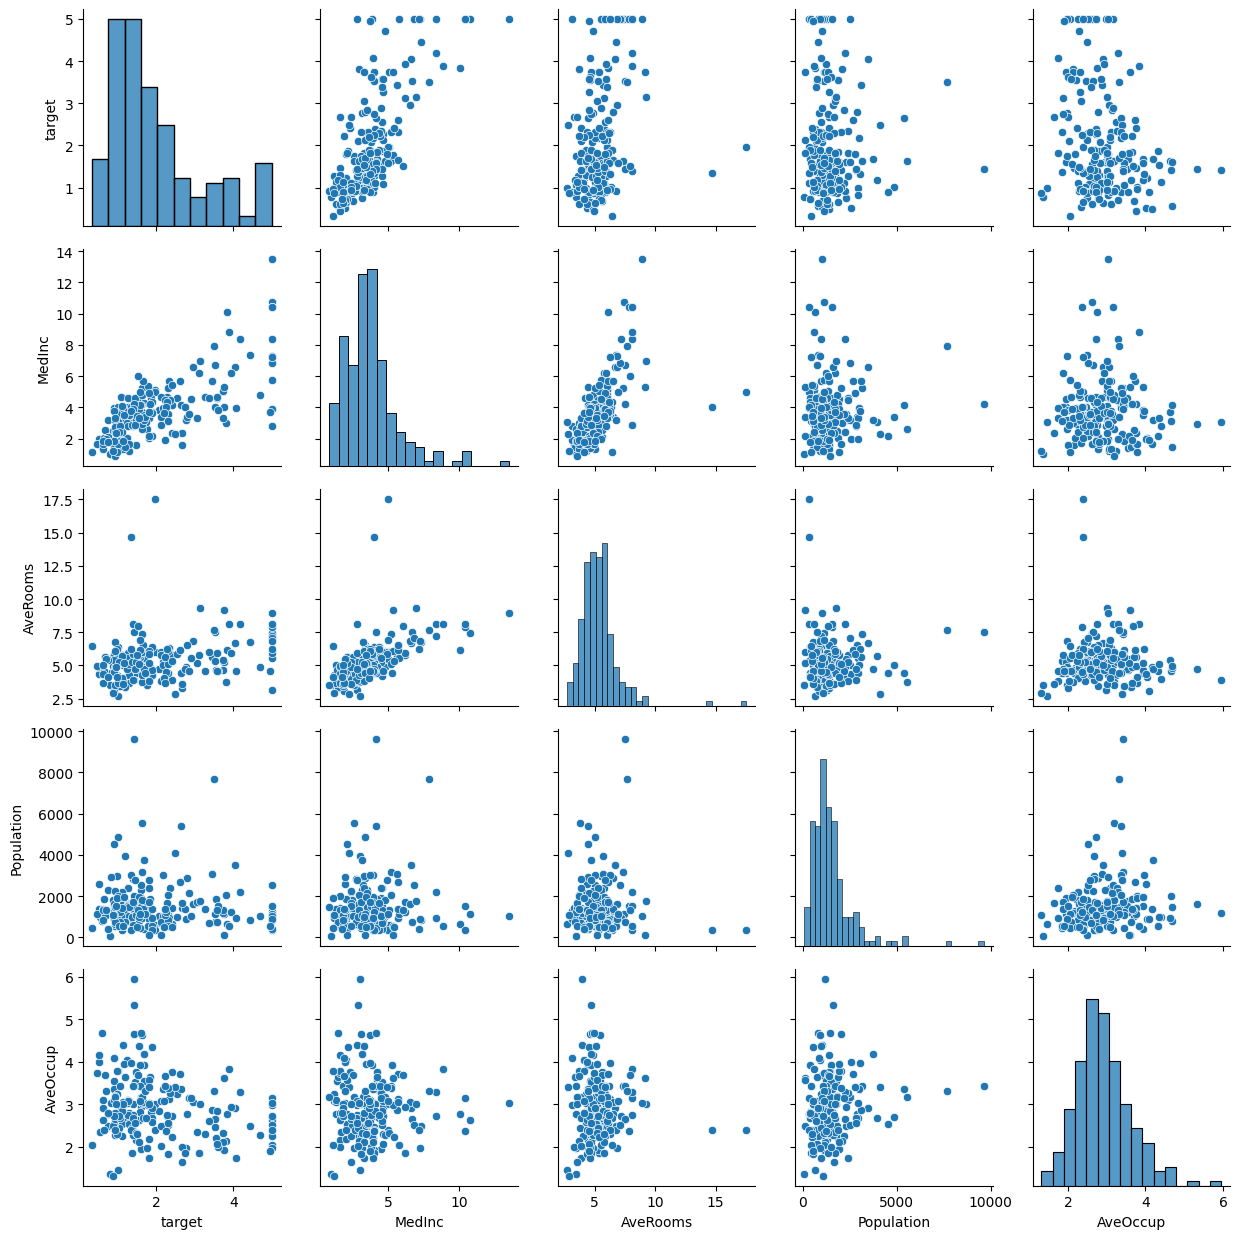

In [8]:
sns.pairplot(df2[cols], height=2.5)
plt.tight_layout()

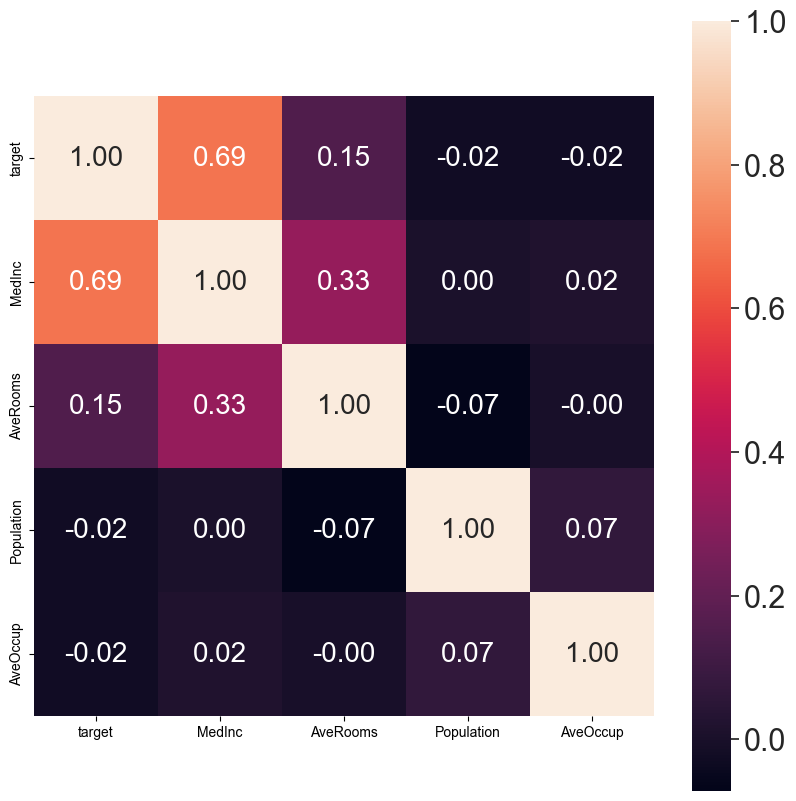

In [9]:
# get correlation matrix to see possible dependencies
cm = np.corrcoef(df[cols].values.T)

fig, ax = plt.subplots(figsize=(10,10))         # Sample figsize in inches

sns.set(font_scale=2)
hm = sns.heatmap(cm, ax=ax, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 20}, yticklabels=cols, xticklabels=cols)


In [10]:
from sklearn import datasets, linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
# one feature
# X = df.drop(columns='target')
X = df[['MedInc']].values
y = df['target'].values

print(X)
print("----"*10)
sc_x = StandardScaler()
sc_y = StandardScaler()
# scaling input and output
X = sc_x.fit_transform(X)
print(X)
print(X.shape)
print("----"*10)
# print(X_std)
y = sc_y.fit_transform(y[:, np.newaxis]).flatten()
print(y)
print(y.shape)
print("----"*10)


# # Split the data into training/testing sets
X_train = X[:-100]
print(X_train.shape)
X_test = X[-100:]
# Split the targets into training/testing sets
y_train = y[:-100]
print(y_train.shape)
y_test = y[-100:]

# Create linear regression object
regr = linear_model.LinearRegression()
# print(X_train.shape)
# Train the model using the training sets
regr.fit(X_train, y_train)

# regr.fit(X_train, y_train)
# # Make predictions using the training set
y_pred = regr.predict(X_train)
print(y_pred.shape)

# The coefficients
print('Coefficients: \n', regr.coef_)
# The intercept
print('Intercept: \n', regr.intercept_)

# The mean squared error
print('Mean squared error: %.2f'
      % mean_squared_error(y_train, y_pred))
# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination (aka R2): %.2f'
      % r2_score(y_train, y_pred))


# # Make predictions using the testing set
y_pred = regr.predict(X_test)
print(y_pred.shape)
# The coefficients
print('Coefficients: \n', regr.coef_)
# The intercept
print('Intercept: \n', regr.intercept_)

# The mean squared error
print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination (aka R2): %.2f'
      % r2_score(y_test, y_pred))


[[8.3252]
 [8.3014]
 [7.2574]
 ...
 [1.7   ]
 [1.8672]
 [2.3886]]
----------------------------------------
[[ 2.34476576]
 [ 2.33223796]
 [ 1.7826994 ]
 ...
 [-1.14259331]
 [-1.05458292]
 [-0.78012947]]
(20640, 1)
----------------------------------------
[ 2.12963148  1.31415614  1.25869341 ... -0.99274649 -1.05860847
 -1.01787803]
(20640,)
----------------------------------------
(20540, 1)
(20540,)
(20540,)
Coefficients: 
 [0.68703256]
Intercept: 
 0.002248132773181232
Mean squared error: 0.53
Coefficient of determination (aka R2): 0.47
(100,)
Coefficients: 
 [0.68703256]
Intercept: 
 0.002248132773181232
Mean squared error: 0.36
Coefficient of determination (aka R2): -0.84


In [11]:
X_train.shape

(20540, 1)

X_inv.shape
(20640, 1)
--------------------------------------------------
X_test -> X_test_inv
X_test.shape
(100, 1)
X_test_inv.shape
(100, 1)
X_inv.shape
(20640, 1)
--------------------------------------------------
--------------------------------------------------
X_test_inv.shape
(100, 1)
y_pred_inv.shape
(100, 1)


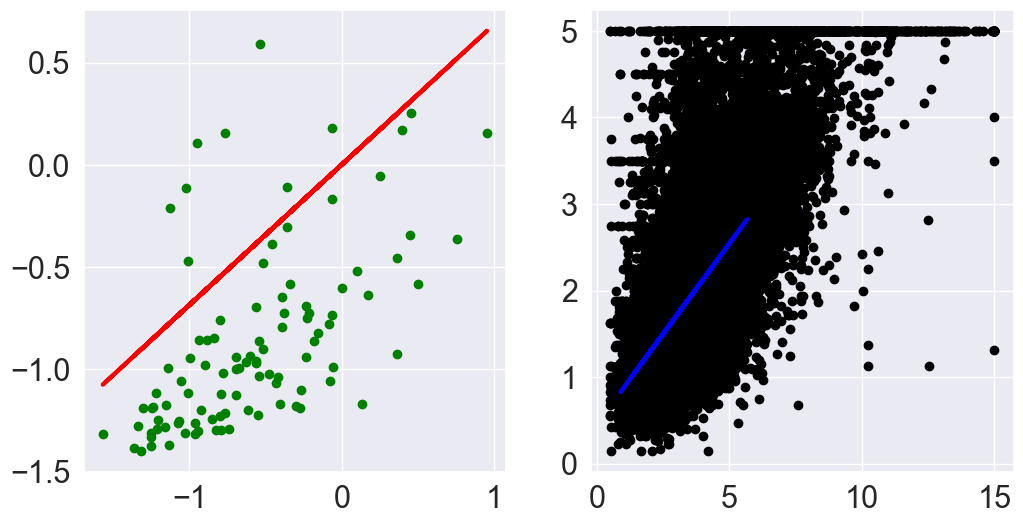

In [27]:
# Plot outputs and check results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(X_test, y_test,  color='green')
ax1.plot(X_test, y_pred, color='red', linewidth=3)


X_inv = X.reshape(-1, 1)
y_inv = y.reshape(-1, 1)
print("X_inv.shape")
print(X_inv.shape)
print("-----"*10)

X_test_inv = X_test.reshape(-1, 1)
y_pred_inv = y_pred.reshape(-1, 1)

print("X_test -> X_test_inv")
print("X_test.shape")
print(X_test.shape)
print("X_test_inv.shape")
print(X_test_inv.shape)

X_inv = sc_x.inverse_transform(X_inv)
y_inv = sc_y.inverse_transform(y_inv)
print("X_inv.shape")
print(X_inv.shape)
print("-----"*10)
X_test_inv = sc_x.inverse_transform(X_test_inv)
y_pred_inv = sc_y.inverse_transform(y_pred_inv)

print("-----"*10)
print("X_test_inv.shape")
print(X_test_inv.shape)
print("y_pred_inv.shape")
print(y_pred_inv.shape)

ax2.scatter(X_inv, y_inv,  color='black')
ax2.plot(X_test_inv, y_pred_inv, color='blue', linewidth=3)


plt.show()

In [13]:
print(X_train)

[[ 2.34476576]
 [ 2.33223796]
 [ 1.7826994 ]
 ...
 [-1.47773814]
 [-0.53125798]
 [ 0.1837738 ]]


In [14]:
# predict from MedInc
# first get proper input format
MedInc = [[3]]
MedInc_std = sc_x.transform(MedInc)
p = regr.predict(MedInc_std)
p = p.reshape(-1, 1)
p_inv_transform = sc_y.inverse_transform(p)
print('price for income median equal', *MedInc[0], 'is', p_inv_transform[0])

price for income median equal 3 is [1.70781683]


# Implement Linear Regression on your own

In [ ]:
class LinearRegressionGD(object):

  def __init__(self, eta=0.0001, n_iter=100):
    self.eta = eta
    self.n_iter = n_iter

  def fit(self, X, y):
    self.w_ = np.zeros(1 + X.shape[1])
    self.cost_ = []
    for i in range(self.n_iter):
      output = self.net_input(X)
      errors = (y - output)
      self.w_[1:] += self.eta * X.T.dot(errors)
      self.w_[0] += self.eta * errors.sum()
      cost = (errors**2).sum() / 2.0
      self.cost_.append(cost)
    return self

  def net_input(self, X):
    return np.dot(X, self.w_[1:]) + self.w_[0]

  def predict(self, X):
    return self.net_input(X)


In [16]:
df3 = df.sample(2000, random_state=1)
print(df3.shape)
X = df3[['MedInc']].values
y = df3['target'].values
sc_x = StandardScaler()
sc_y = StandardScaler()
# scaling input and output
X_std = sc_x.fit_transform(X)
# print(X_std)
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()
lr = LinearRegressionGD()
lr.fit(X_std, y_std)

(2000, 9)


In [17]:
y.shape

(2000,)

In [18]:
y[:, np.newaxis].shape

(2000, 1)

In [19]:
y[:, np.newaxis].flatten().shape

(2000,)

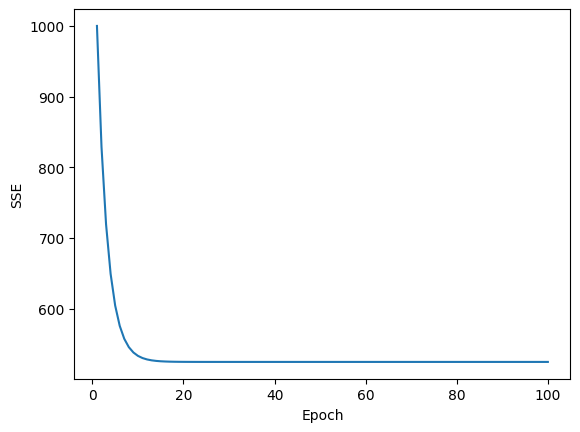

In [20]:
sns.reset_orig() # resets matplotlib style
plt.plot(range(1, lr.n_iter+1), lr.cost_)
plt.ylabel('SSE')
plt.xlabel('Epoch')
plt.show()



Text(0, 0.5, 'Price in $1000s (standardized)')

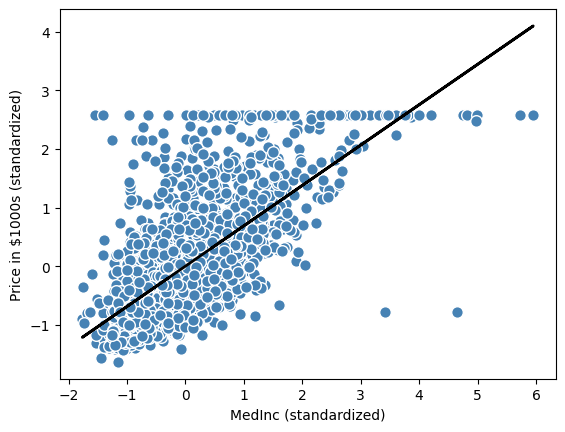

In [21]:
plt.scatter(X_std, y_std, c='steelblue', edgecolor='white', s=70)
plt.plot(X_std, lr.predict(X_std), color='black', lw=2)
plt.xlabel('MedInc (standardized)')
plt.ylabel('Price in $1000s (standardized)')


In [22]:
# get price for given median income
medinc_std = sc_x.transform([[3.0]])
# print(num_rooms_std)
# num_rooms_std = num_rooms_std.reshape(1,-1)
price_std = lr.predict(medinc_std)
# print(price_std)
print("Price in $1000s for MedInc=3: %.3f" % sc_y.inverse_transform(price_std.reshape(-1,1)))


Price in $1000s for MedInc=3: 1.685


<ipython-input-22-4248149815>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Price in $1000s for MedInc=3: %.3f" % sc_y.inverse_transform(price_std.reshape(-1,1)))


In [23]:
# get params of lin regression
print('Slope: %.3f' % lr.w_[1])
print('Intercept: %.3f' % lr.w_[0])


Slope: 0.689
Intercept: -0.000


# Logistic Regression
 - Classifficaon of iris dataset

In [24]:
df= pd.DataFrame(data= np.c_[iris['data'], iris['target']],columns= list(iris['feature_names']) + ['target'])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [25]:
from sklearn.linear_model import LogisticRegression

# iris

X = df[['sepal length (cm)','sepal width (cm)']]  # we only take the first two features for displaying purposes here
y = df['target']

print(X.shape, y.shape)
# Create an instance of Logistic Regression Classifier and fit the data.
logreg = LogisticRegression()
logreg.fit(X, y)

logreg.score(X, y)

# check what happens when another features are used

(150, 2) (150,)


0.82

       sepal length (cm)  sepal width (cm)
0                   3.80               1.5
1                   3.82               1.5
2                   3.84               1.5
3                   3.86               1.5
4                   3.88               1.5
...                  ...               ...
39496               8.32               4.9
39497               8.34               4.9
39498               8.36               4.9
39499               8.38               4.9
39500               8.40               4.9

[39501 rows x 2 columns]


([], [])

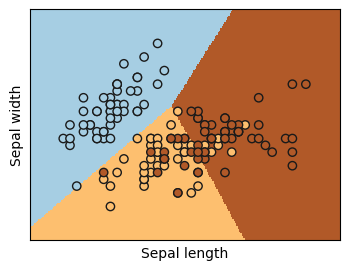

In [26]:
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X.values[:, 0].min() - .5, X.values[:, 0].max() + .5
y_min, y_max = X.values[:, 1].min() - .5, X.values[:, 1].max() + .5
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()])
data.columns = ['sepal length (cm)','sepal width (cm)']
print(data)
Z = logreg.predict(data)

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1, figsize=(4, 3))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)


# Plot also the training points
plt.scatter(X.values[:, 0], X.values[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

In [27]:
print(xx)
print(yy)
print(np.c_[xx.ravel(), yy.ravel()])

[[3.8  3.82 3.84 ... 8.36 8.38 8.4 ]
 [3.8  3.82 3.84 ... 8.36 8.38 8.4 ]
 [3.8  3.82 3.84 ... 8.36 8.38 8.4 ]
 ...
 [3.8  3.82 3.84 ... 8.36 8.38 8.4 ]
 [3.8  3.82 3.84 ... 8.36 8.38 8.4 ]
 [3.8  3.82 3.84 ... 8.36 8.38 8.4 ]]
[[1.5  1.5  1.5  ... 1.5  1.5  1.5 ]
 [1.52 1.52 1.52 ... 1.52 1.52 1.52]
 [1.54 1.54 1.54 ... 1.54 1.54 1.54]
 ...
 [4.86 4.86 4.86 ... 4.86 4.86 4.86]
 [4.88 4.88 4.88 ... 4.88 4.88 4.88]
 [4.9  4.9  4.9  ... 4.9  4.9  4.9 ]]
[[3.8  1.5 ]
 [3.82 1.5 ]
 [3.84 1.5 ]
 ...
 [8.36 4.9 ]
 [8.38 4.9 ]
 [8.4  4.9 ]]


In [28]:
print(logreg.coef_) # feature importance, dependance direction (sign), ndarray of shape (1, n_features) or (n_classes, n_features)

[[-2.70858405  2.32402607]
 [ 0.61260073 -1.57100532]
 [ 2.09598332 -0.75302075]]


# SVM

In [29]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(X, y)
print("Accuracy on training set: {:.2f}".format(svc.score(X, y)))
# print("Accuracy on test set: {:.2f}".format(svc.score(X, y)))


Accuracy on training set: 0.82


In [30]:
svc.coef_

array([[-2.22720466,  2.24959915],
       [-2.06931629,  1.72277136],
       [-1.60096201, -0.79648515]])

### Effect of kernel and parameters

In [28]:
svc = SVC(kernel='rbf', C=1, gamma=10)
svc.fit(X, y)
print("Accuracy on training set: {:.2f}".format(svc.score(X, y)))
print("Accuracy on test set: {:.2f}".format(svc.score(X, y)))

# coef_ parameter = weights assigned to the features (coefficients in the primal problem). Only available in the case of a linear kernel.



NameError: name 'SVC' is not defined

In [32]:
svc.score(X, y)

0.84

# Decision Trees

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
# print(cancer.DESCR)
df= pd.DataFrame(data= np.c_[cancer['data'], cancer['target']],columns= list(cancer['feature_names']) + ['target'])

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42) # stratify preserves the class ratios
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))
# df
# overfitting because of full tree with pure leaves

Accuracy on training set: 1.000
Accuracy on test set: 0.937


### Prunning!
 - restrict the depth of a decision tree
 - otherwise the tree can become arbitrarily deep and complex
 - unpruned trees are therefore prone to overfitting and not generalizing
well to new data

#### Build again
- let’s apply pre-pruning to the tree, which will stop developing
the tree before we perfectly fit to the training data
- one option is to stop building the tree after a certain depth has been reached. Here we set max_depth=4, meaning only four consecutive questions can be asked
- limiting the depth of the tree decreases overfitting
- this leads to a lower accuracy on the trainin set, but an improvement on the test set


In [34]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))


Accuracy on training set: 0.988
Accuracy on test set: 0.951


### Analyzing the tree

In [35]:
from sklearn.tree import export_graphviz
export_graphviz(tree, out_file="tree.dot", class_names=["malignant", "benign"], feature_names=cancer.feature_names, impurity=False, filled=True)


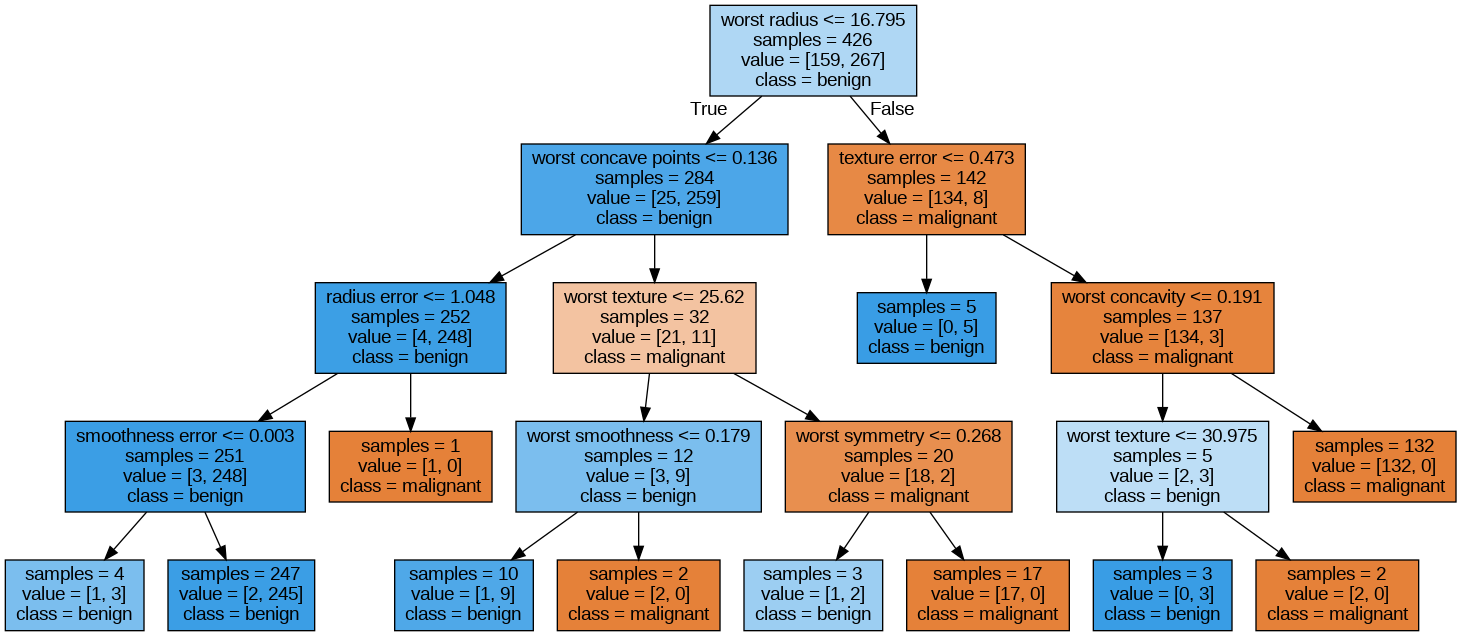

In [36]:
import graphviz
from IPython.display import Image

with open("tree.dot") as f:
  dot_graph = f.read()
graph = graphviz.Source(dot_graph)
graph.render("tree", format="png", cleanup=True)
Image("tree.png")


### Feature Importance


In [37]:
importance = tree.feature_importances_
print(len(importance),  ' predictive attributes/features')

for i,v in enumerate(importance):
	print('Feature: %0s, Score: %.5f' % (df.columns[i],v))
# plt.bar([x for x in range(len(importance))], importance)



30  predictive attributes/features
Feature: mean radius, Score: 0.00000
Feature: mean texture, Score: 0.00000
Feature: mean perimeter, Score: 0.00000
Feature: mean area, Score: 0.00000
Feature: mean smoothness, Score: 0.00000
Feature: mean compactness, Score: 0.00000
Feature: mean concavity, Score: 0.00000
Feature: mean concave points, Score: 0.00000
Feature: mean symmetry, Score: 0.00000
Feature: mean fractal dimension, Score: 0.00000
Feature: radius error, Score: 0.01020
Feature: texture error, Score: 0.04840
Feature: perimeter error, Score: 0.00000
Feature: area error, Score: 0.00000
Feature: smoothness error, Score: 0.00242
Feature: compactness error, Score: 0.00000
Feature: concavity error, Score: 0.00000
Feature: concave points error, Score: 0.00000
Feature: symmetry error, Score: 0.00000
Feature: fractal dimension error, Score: 0.00000
Feature: worst radius, Score: 0.72683
Feature: worst texture, Score: 0.04582
Feature: worst perimeter, Score: 0.00000
Feature: worst area, Score:

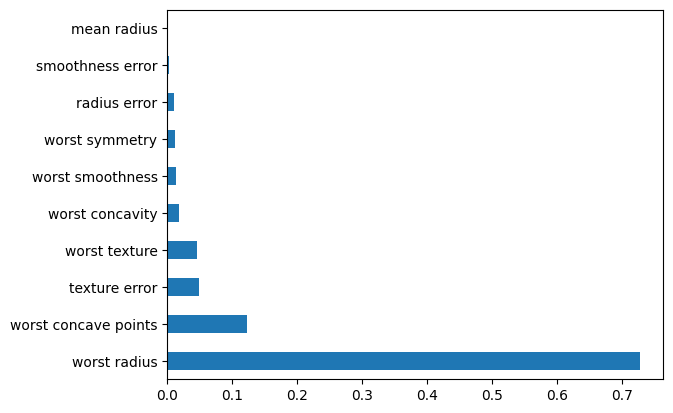

In [38]:
# plot with feature names
s = pd.Series(importance, index=df.columns[:-1]).nlargest(10).plot(kind='barh')

### Ensemble methods

In [39]:
from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=7)

forest = RandomForestClassifier(n_estimators=5, random_state=0)
forest.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(forest.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test, y_test)))

forest = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=0)
forest.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(forest.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test, y_test)))

forest.feature_importances_

Accuracy on training set: 0.995
Accuracy on test set: 0.958
Accuracy on training set: 0.991
Accuracy on test set: 0.972


array([0.03375728, 0.01357815, 0.05378484, 0.03536351, 0.00507722,
       0.00389859, 0.08387652, 0.07256357, 0.00153227, 0.00191283,
       0.02200079, 0.00213545, 0.01249127, 0.03139741, 0.00318609,
       0.00255546, 0.00299522, 0.00701629, 0.00321919, 0.00343266,
       0.13023684, 0.01356881, 0.18115919, 0.07829777, 0.01028316,
       0.01009687, 0.03560736, 0.1310055 , 0.00810955, 0.00586037])

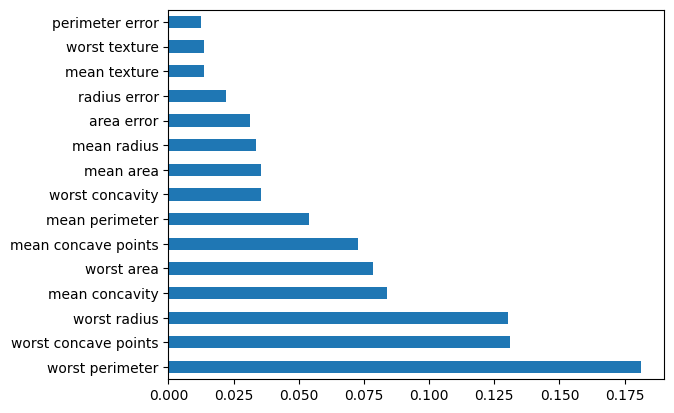

In [40]:
importance = forest.feature_importances_
s = pd.Series(importance, index=df.columns[:-1]).nlargest(15).plot(kind='barh')


### Prediction probabilities - estimation uncertainty

In [41]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=42)

logreg = LogisticRegression(C=1e5, max_iter=1000)
logreg.fit(X_train, y_train)

print("Decision function shape: {}".format(logreg.decision_function(X_test).shape))
# plot the first few entries of the decision function
print("Decision function:\n{}".format(logreg.decision_function(X_test)[:6, :]))

# Decision_function has the shape (n_samples, n_classes) and each column provides confidence scores for each class.
# The confidence score for a sample is proportional to the signed distance of that sample to the hyperplane.

Decision function shape: (38, 3)
Decision function:
[[-15.94706004  12.47991238   3.46714766]
 [ 44.16158213   5.1358679  -49.29745003]
 [-50.84035159  12.89819752  37.94215406]
 [-14.48193206  10.35797684   4.12395523]
 [-15.351015    10.8874788    4.4635362 ]
 [ 40.64973975   5.21841439 -45.86815415]]


In [42]:
# show the first few entries of predict_proba
print("Predicted probabilities:\n{}".format(logreg.predict_proba(X_test)[:6]))
# show that sums across rows are one
print("Sums: {}".format(logreg.predict_proba(X_test)[:6].sum(axis=1)))


Predicted probabilities:
[[4.51096886e-13 9.99878170e-01 1.21829680e-04]
 [1.00000000e+00 1.12550560e-17 2.57785243e-41]
 [2.76852026e-39 1.32907004e-11 1.00000000e+00]
 [1.62672289e-11 9.98042293e-01 1.95770730e-03]
 [4.01849071e-12 9.98380380e-01 1.61962032e-03]
 [1.00000000e+00 4.09610338e-16 2.66536133e-38]]
Sums: [1. 1. 1. 1. 1. 1.]


In [43]:
# We can again recover the predictions by computing the argmax of predict_proba:
print("Argmax of predicted probabilities:\n{}".format(
np.argmax(logreg.predict_proba(X_test), axis=1)))
print("Predictions:\n{}".format(logreg.predict(X_test)))


Argmax of predicted probabilities:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


**KNN**

In [44]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=knei#sklearn.neighbors.KNeighborsClassifier
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html?highlight=knei#sklearn.neighbors.KNeighborsRegressor


In [45]:
df= pd.DataFrame(data= np.c_[cancer['data'], cancer['target']],columns= list(cancer['feature_names']) + ['target'])

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=66) # stratify preserves the class ratios
clf = KNeighborsClassifier(n_neighbors=6)
clf.fit(X_train, y_train)
print("Test set predictions: {}".format(clf.predict(X_test)))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))


Test set predictions: [1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 0 0 1 0
 1 1 0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0
 1 0 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1
 0 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1]
Test set accuracy: 0.94


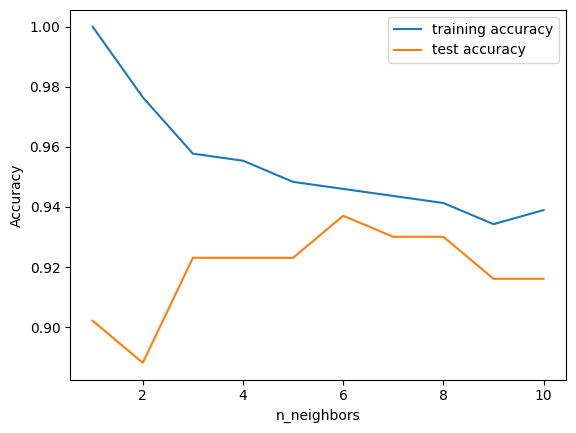

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, stratify=cancer.target, random_state=66)
training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)
for n_neighbors in neighbors_settings:
  # build the model
  clf = KNeighborsClassifier(n_neighbors=n_neighbors)
  clf.fit(X_train, y_train)
  # record training set accuracy
  training_accuracy.append(clf.score(X_train, y_train))
  # record generalization accuracy
  test_accuracy.append(clf.score(X_test, y_test))
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()


# Convert jupyter notebook to html

In [47]:
# this is how to mount google drive to be usable and reachable as data storage
# from google.colab import drive
# drive.mount('/content/drive')

In [48]:
# convert colab nb to html
# %%shell
# !jupyter-nbconvert --to html /content/drive/MyDrive/Teaching/MLP/2023_autumn/W2-Supervised_Learning.ipynb
# !jupyter nbconvert --to html /content/drive/MyDrive/Teaching/MLP/2023_autumn/W2-Supervised_Learning.py
